## Notebook 3: RF Model, Hyperparameter Tuning & Evaluation - Phase 3

### Objectives:
1. Load feature matrix from Phase 2
2. Accuracy improvements - feature selection, calibration
3. Hyperparameter tuning with TimeSeriesSplit
4. Four RF configurations evaluated:
   - RF Static (baseline)
   - RF Walk-Forward (retrain every 6 months)
   - RF + VIX Regime Filter
   - RF Walk-Forward + VIX Filter (best combined)
5. Benchmarks: Buy & Hold, Random Model
6. Statistical significance: Diebold-Mariano + Bootstrap Sharpe CI
7. Full results table, equity curves, feature importance
8. Annual performance breakdown

## 1. Imports & Config

In [61]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from dateutil.relativedelta import relativedelta
import joblib

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.feature_selection import SelectFromModel
from pathlib import Path

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Anchor paths to the notebook's directory
BASE_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()

FIG_DIR = BASE_DIR / 'figures' / 'Evaluation'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Configuration matching Phase 1 & 2
TICKER           = 'SPY'
TRAIN_END        = '2020-12-31'
TEST_START       = '2021-01-01'
TRANSACTION_COST = 0.0005
RISK_FREE_RATE   = 0.02
VIX_THRESHOLD    = 25
RETRAIN_MONTHS   = 6
N_BOOTSTRAP      = 10_000

print('All dependencies loaded.')

All dependencies loaded.


## 2. Load Data

In [62]:
features = pd.read_csv(DATA_DIR / 'SPY_features.csv', index_col=0, parse_dates=True)
features.sort_index(inplace=True)

feature_cols = pd.read_csv(DATA_DIR / 'feature_cols.csv', header=None)[0].tolist()

X = features[feature_cols].copy()
y = features['target'].copy()

X_train = X.loc[:TRAIN_END]
X_test  = X.loc[TEST_START:]
y_train = y.loc[:TRAIN_END]
y_test  = y.loc[TEST_START:]

raw = pd.read_csv(DATA_DIR / 'SPY_clean_data.csv', index_col=0, parse_dates=True)
raw.sort_index(inplace=True)
returns_test = raw.loc[TEST_START:, 'simple_return'].reindex(X_test.index)
vix_test     = features.loc[TEST_START:, 'VIX'].reindex(X_test.index)

print(f'Feature matrix: {X.shape}')
print(f'Training: {X_train.shape} | Test: {X_test.shape}')
print(f'Test period: {X_test.index[0].date()} → {X_test.index[-1].date()}')
print(f'\nClass balance (train): Up={y_train.mean()*100:.1f}% | Down={(1-y_train.mean())*100:.1f}%')

Feature matrix: (2214, 45)
Training: (1461, 45) | Test: (753, 45)
Test period: 2021-01-04 → 2023-12-29

Class balance (train): Up=55.2% | Down=44.8%


## 3. Accuracy Improvements

Two techniques applied before training:

1. **Feature selection** - remove low-importance features that add noise.
2. **Expanded hyperparameter grid** - wider search including `min_samples_leaf`.

In [63]:
# 3a. Feature selection
selector_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
selector_rf.fit(X_train, y_train)

selector         = SelectFromModel(selector_rf, threshold='mean', prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected  = selector.transform(X_test)
selected_features = np.array(feature_cols)[selector.get_support()]

print(f'Features before selection : {len(feature_cols)}')
print(f'Features after selection  : {len(selected_features)}')
print(f'\nSelected features:')
for f in selected_features:
    print(f'  {f}')

Features before selection : 45
Features after selection  : 20

Selected features:
  price_vs_ema20
  adx_pos
  bb_width
  bb_pct_b
  obv_zscore
  vol_ratio
  log_return_lag1
  log_return_lag2
  log_return_lag5
  rsi_14_lag5
  macd_diff_lag5
  bb_pct_b_lag5
  vol_ratio_lag1
  vol_ratio_lag2
  vol_ratio_lag5
  return_lag1
  return_lag2
  return_lag3
  return_lag4
  return_lag5


In [64]:
param_grid = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [5, 10, 15],
    'min_samples_split': [20, 50],
    'min_samples_leaf' : [10, 20],
    'max_features'     : ['sqrt', 0.3],
}

tscv    = TimeSeriesSplit(n_splits=5)
base_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

total = 1
for v in param_grid.values():
    total *= len(v)
print(f'Total combinations : {total}  |  Total CV fits: {total * 5}')
print('Running grid search...')

grid_search = GridSearchCV(
    estimator  = base_rf,
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)
grid_search.fit(X_train_selected, y_train)

best_rf = grid_search.best_estimator_

print(f'\nBest parameters   : {grid_search.best_params_}')
print(f'Best in-sample AUC: {grid_search.best_score_:.4f}')

Total combinations : 72  |  Total CV fits: 360
Running grid search...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters   : {'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 200}
Best in-sample AUC: 0.5183


## 4. Metric Functions

In [65]:
def sharpe_ratio(returns, risk_free_rate=RISK_FREE_RATE, periods=252):
    daily_rf = risk_free_rate / periods
    excess   = returns - daily_rf
    if excess.std() == 0:
        return 0.0
    return (excess.mean() / excess.std()) * np.sqrt(periods)

def win_ratio(returns, signal=None):
    active = returns[signal == 1] if signal is not None else returns
    if len(active) == 0:
        return 0.0
    return (active > 0).sum() / len(active)

def max_drawdown(returns):
    cum         = (1 + returns).cumprod()
    rolling_max = cum.cummax()
    return ((cum - rolling_max) / rolling_max).min()

def cagr(returns, periods=252):
    total = (1 + returns).prod()
    n_yrs = len(returns) / periods
    return total ** (1 / n_yrs) - 1

def calmar_ratio(returns, periods=252):
    mdd = max_drawdown(returns)
    return cagr(returns, periods) / abs(mdd) if mdd != 0 else np.nan

def compute_metrics(returns, signal=None):
    dim = signal.mean() * 100 if signal is not None else 100.0
    return {
        'Sharpe Ratio' : round(sharpe_ratio(returns), 3),
        'Win Ratio'    : round(win_ratio(returns, signal=signal), 3),
        'CAGR'         : round(cagr(returns), 3),
        'Max Drawdown' : round(max_drawdown(returns), 3),
        'Calmar Ratio' : round(calmar_ratio(returns), 3),
        'Total Return' : round((1 + returns).prod() - 1, 3),
        'Days In %'    : round(dim, 1),
    }

print('Metric functions defined.')

Metric functions defined.


## 5. RF Variant 1 - Static Baseline

This is the simplest Random Forest setup: train once on the training set, then use the same fitted model to predict the full test period.
It gives a baseline to compare against the more adaptive variants below.

In [66]:
# Out-of-sample predictions - uncalibrated RF
y_pred_static  = best_rf.predict(X_test_selected)
y_proba_static = best_rf.predict_proba(X_test_selected)[:, 1]

acc_static = accuracy_score(y_test, y_pred_static)
auc_static = roc_auc_score(y_test, y_proba_static)

print('=== Variant 1: RF Static - Classification Report ===')
print(classification_report(y_test, y_pred_static, target_names=['Down', 'Up']))
print(f'Accuracy : {acc_static:.4f}')
print(f'AUC-ROC  : {auc_static:.4f}')

# Signal sanity check
print(f'\nSignal distribution:')
print(f'  Up (1)   : {(y_pred_static==1).sum()} days')
print(f'  Down (0) : {(y_pred_static==0).sum()} days')
print(f'  Proba range: [{y_proba_static.min():.3f}, {y_proba_static.max():.3f}]')

# Regime diagnostic
temp_df  = pd.DataFrame({'ret': returns_test.values, 'sig': y_pred_static}, index=X_test.index)
long_ret = temp_df[temp_df['sig']==1]['ret'].mean()
flat_ret = temp_df[temp_df['sig']==0]['ret'].mean()
print(f'\nMarket return on LONG days : {long_ret:.4f}')
print(f'Market return on FLAT days : {flat_ret:.4f}')
if flat_ret > long_ret:
    print('Note: model is picking wrong days - regime shift present.')

=== Variant 1: RF Static - Classification Report ===
              precision    recall  f1-score   support

        Down       0.50      0.30      0.38       358
          Up       0.53      0.72      0.61       395

    accuracy                           0.52       753
   macro avg       0.52      0.51      0.50       753
weighted avg       0.52      0.52      0.50       753

Accuracy : 0.5232
AUC-ROC  : 0.5190

Signal distribution:
  Up (1)   : 536 days
  Down (0) : 217 days
  Proba range: [0.358, 0.679]

Market return on LONG days : -0.0002
Market return on FLAT days : 0.0021
Note: model is picking wrong days - regime shift present.


In [67]:
# Build base backtest dataframe
backtest = pd.DataFrame(index=X_test.index)
backtest['actual_return'] = returns_test.values
backtest['rf_signal']     = y_pred_static
backtest['rf_proba']      = y_proba_static
backtest['vix']           = vix_test.values

# Static RF
sig_changes = backtest['rf_signal'].diff().abs().fillna(1)
backtest['rf_static_return'] = (
    backtest['actual_return'] * backtest['rf_signal']
    - sig_changes * TRANSACTION_COST
)

# Buy & Hold
backtest['bh_return'] = backtest['actual_return'].copy()
backtest.iloc[0, backtest.columns.get_loc('bh_return')] -= TRANSACTION_COST

# Random Model
np.random.seed(RANDOM_SEED)
rand_sig = np.random.randint(0, 2, size=len(backtest))
rand_chg = pd.Series(rand_sig).diff().abs().fillna(1).values
backtest['random_return'] = (
    backtest['actual_return'].values * rand_sig - rand_chg * TRANSACTION_COST
)
backtest['random_signal'] = rand_sig

print(f'Backtest: {len(backtest)} trading days')
print(f'RF Static - trades: {int(sig_changes.sum())} | days long: {backtest["rf_signal"].mean()*100:.1f}%')

Backtest: 753 trading days
RF Static - trades: 263 | days long: 71.2%


## 6. RF Variant 2 - Walk-Forward Retraining

This variant retrains the Random Forest every 6 months using all data available up to that point.
The goal is to let the model adapt to changing market conditions instead of relying on one fixed training period.

In [68]:
test_index   = X_test.index
wf_preds     = pd.Series(index=test_index, dtype=int)
wf_probas    = pd.Series(index=test_index, dtype=float)
current_date = pd.Timestamp(TEST_START)
end_date     = test_index[-1]

print('Walk-forward retraining...')
while current_date <= end_date:
    next_date = current_date + relativedelta(months=RETRAIN_MONTHS)
    next_date = min(next_date, end_date + pd.Timedelta(days=1))

    X_wf_train_full  = X.loc[:current_date - pd.Timedelta(days=1)]
    y_wf_train       = y.loc[:current_date - pd.Timedelta(days=1)]
    X_wf_train_sel   = selector.transform(X_wf_train_full)
    X_wf_window_full = X.loc[current_date : next_date - pd.Timedelta(days=1)]
    X_wf_window_sel  = selector.transform(X_wf_window_full)

    if len(X_wf_train_sel) < 200 or len(X_wf_window_sel) == 0:
        current_date = next_date
        continue

    wf_rf = RandomForestClassifier(
        **grid_search.best_params_,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    wf_rf.fit(X_wf_train_sel, y_wf_train)

    wf_preds[X_wf_window_full.index]  = wf_rf.predict(X_wf_window_sel)
    wf_probas[X_wf_window_full.index] = wf_rf.predict_proba(X_wf_window_sel)[:, 1]

    print(f'  {current_date.date()} → {(next_date - pd.Timedelta(days=1)).date()} | '
          f'train={len(X_wf_train_sel)} | test={len(X_wf_window_sel)}')
    current_date = next_date

backtest['wf_signal'] = wf_preds.values
backtest['wf_proba']  = wf_probas.values
wf_chg = backtest['wf_signal'].diff().abs().fillna(1)
backtest['wf_return'] = (
    backtest['actual_return'] * backtest['wf_signal']
    - wf_chg * TRANSACTION_COST
)

wf_acc = accuracy_score(y_test, wf_preds)
wf_auc = roc_auc_score(y_test, wf_probas)
print(f'\nWalk-Forward Accuracy: {wf_acc:.4f} | AUC-ROC: {wf_auc:.4f}')
print(f'Trades: {int(wf_chg.sum())} | Days long: {backtest["wf_signal"].mean()*100:.1f}%')

Walk-forward retraining...
  2021-01-01 → 2021-06-30 | train=1461 | test=124
  2021-07-01 → 2021-12-31 | train=1585 | test=128
  2022-01-01 → 2022-06-30 | train=1713 | test=124
  2022-07-01 → 2022-12-31 | train=1837 | test=127
  2023-01-01 → 2023-06-30 | train=1964 | test=124
  2023-07-01 → 2023-12-29 | train=2088 | test=126

Walk-Forward Accuracy: 0.5086 | AUC-ROC: 0.5118
Trades: 289 | Days long: 64.7%


## 7. RF Variant 3 - VIX Regime Filter

This variant keeps the static RF signal, but only takes long positions when market stress is low enough based on the VIX threshold.
The idea is to avoid trading during high-volatility regimes where the model is less reliable.

In [69]:
# 7. RF Variant 3 — VIX Regime Filter
# Threshold selected on TRAINING data only (no test leakage)
from sklearn.base import clone

candidate_thresholds = [20, 25, 30]

# --- Step 1: Generate OOF signals on training set ---
train_index  = X_train.index
rf_train_oof = pd.Series(index=train_index, dtype=float)

tscv_thresh = TimeSeriesSplit(n_splits=5)
for tr_idx, val_idx in tscv_thresh.split(X_train_selected):
    rf_fold = clone(best_rf)
    rf_fold.fit(X_train_selected[tr_idx], y_train.iloc[tr_idx])
    rf_train_oof.iloc[val_idx] = rf_fold.predict(
        X_train_selected[val_idx]
    )

# Keep only rows that have OOF predictions (first fold has no val)
mask       = rf_train_oof.notna()
train_eval = pd.DataFrame(index=train_index[mask])
train_eval['rf_signal']     = rf_train_oof[mask].astype(int).values
train_eval['vix']           = features.loc[train_index[mask], 'VIX'].values
train_eval['actual_return'] = raw.loc[train_index[mask], 'simple_return'].values

# --- Step 2: Score each threshold on TRAINING folds only ---
print('Train-only threshold search (OOF, TimeSeriesSplit):')
threshold_scores = []

for thresh in candidate_thresholds:
    sig = np.where(
        (train_eval['rf_signal'] == 1) & (train_eval['vix'] < thresh), 1, 0
    )
    chg = pd.Series(sig).diff().abs().fillna(1).values
    ret = pd.Series(
        train_eval['actual_return'] * sig - chg * TRANSACTION_COST,
        index=train_eval.index
    )
    sig_s = pd.Series(sig, index=train_eval.index)
    sh    = sharpe_ratio(ret)
    threshold_scores.append((thresh, sh))
    print(f'  VIX < {thresh} | Sharpe: {sh:.3f} | '
          f'Win: {win_ratio(ret, signal=sig_s):.3f} | '
          f'Days in: {sig.mean()*100:.1f}%')

# --- Step 3: Lock best threshold ---
best_thresh    = max(threshold_scores, key=lambda x: x[1])[0]
VIX_THRESHOLD  = int(best_thresh)
print(f'\nSelected threshold from TRAIN only: VIX < {VIX_THRESHOLD}')

# --- Step 4: Apply locked threshold to TEST set ---
vix_sig = np.where(
    (backtest['rf_signal'] == 1) & (backtest['vix'] < VIX_THRESHOLD), 1, 0
)
vix_chg = pd.Series(vix_sig).diff().abs().fillna(1).values
backtest['vix_signal'] = vix_sig
backtest['vix_return'] = pd.Series(
    backtest['actual_return'].values * vix_sig - vix_chg * TRANSACTION_COST,
    index=backtest.index
)
print(f'Applied selected threshold to TEST set.')

Train-only threshold search (OOF, TimeSeriesSplit):
  VIX < 20 | Sharpe: 0.369 | Win: 0.551 | Days in: 33.7%
  VIX < 25 | Sharpe: -0.317 | Win: 0.528 | Days in: 40.7%
  VIX < 30 | Sharpe: -0.552 | Win: 0.516 | Days in: 44.9%

Selected threshold from TRAIN only: VIX < 20
Applied selected threshold to TEST set.


## 8. RF Variant 4 - Walk-Forward + VIX Filter

This is the combined version: the model is retrained over time and its signals are filtered by the VIX rule.
It is designed to capture both benefits at once: adaptation to regime change and reduced exposure in stressed markets.

In [70]:
combined_sig = np.where(
    (backtest['wf_signal'] == 1) & (backtest['vix'] < VIX_THRESHOLD), 1, 0
)
combined_chg = pd.Series(combined_sig).diff().abs().fillna(1).values
backtest['combined_signal'] = combined_sig
backtest['combined_return'] = pd.Series(
    backtest['actual_return'].values * combined_sig - combined_chg * TRANSACTION_COST,
    index=backtest.index
)

print('=== All Four RF Variants - Quick Summary ===')
variants = {
    'RF Static'          : ('rf_static_return', 'rf_signal'),
    'RF Walk-Forward'    : ('wf_return',         'wf_signal'),
    'RF + VIX Filter'    : ('vix_return',        'vix_signal'),
    'RF WF + VIX Filter' : ('combined_return',   'combined_signal'),
}
for name, (ret_col, sig_col) in variants.items():
    ret = backtest[ret_col]
    sig = backtest[sig_col]
    print(f'{name:<24} Sharpe: {sharpe_ratio(ret):>7.3f} | '
          f'Win: {win_ratio(ret, signal=sig):.3f} | '
          f'CAGR: {cagr(ret):>7.3f} | '
          f'Days in: {sig.mean()*100:.1f}%')

=== All Four RF Variants - Quick Summary ===
RF Static                Sharpe:  -0.685 | Win: 0.481 | CAGR:  -0.091 | Days in: 71.2%
RF Walk-Forward          Sharpe:  -0.731 | Win: 0.472 | CAGR:  -0.097 | Days in: 64.7%
RF + VIX Filter          Sharpe:   1.354 | Win: 0.573 | CAGR:   0.114 | Days in: 34.8%
RF WF + VIX Filter       Sharpe:   1.054 | Win: 0.557 | CAGR:   0.090 | Days in: 30.3%


## 9. Statistical Significance Testing

Good backtest results do not always mean the model has a real edge. Sometimes performance looks strong just because of luck in one sample period.

We use statistical significance testing to check whether the results are likely to be real or just random noise.

- **McNemar test** checks whether the RF classifier makes meaningfully different prediction errors compared with simple benchmarks.
- **Block bootstrap Sharpe CI** checks whether the strategy's Sharpe ratio stays strong after accounting for uncertainty in financial time series.

In short: performance metrics show how good the model looks, while significance tests show how much confidence we should have in those results.

In [71]:
# -------------------------------------------------------
# McNemar test — correct test for binary classifier comparison
# H0: RF and random model have the same error rate
# -------------------------------------------------------
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(actual, pred1, pred2):
    """
    Compare two binary classifiers using McNemar's test.
    Returns chi-square statistic and p-value.
    Significant p < 0.05 means the two classifiers
    make meaningfully different errors.
    """
    # Contingency table of disagreements
    b = np.sum((pred1 != actual) & (pred2 == actual))  # pred2 right, pred1 wrong
    c = np.sum((pred1 == actual) & (pred2 != actual))  # pred1 right, pred2 wrong

    table = [[0, b], [c, 0]]
    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue

actual     = y_test.values
rand_d     = backtest['random_signal'].values
bh_d       = np.ones(len(actual), dtype=int)

print('=== McNemar Test — Binary Classifier Comparison ===')
print('H0: Two classifiers make the same proportion of errors')
print()
for name, pred in [
    ('RF Static',          y_pred_static),
    ('RF Walk-Forward',    wf_preds.values),
]:
    chi_r, pv_r = mcnemar_test(actual, pred.astype(int), rand_d.astype(int))
    chi_b, pv_b = mcnemar_test(actual, pred.astype(int), bh_d.astype(int))
    sig_r = '✓ sig' if pv_r < 0.05 else '✗ n.s.'
    sig_b = '✓ sig' if pv_b < 0.05 else '✗ n.s.'
    print(f'{name:<24} vs Random: χ²={chi_r:>6.3f} p={pv_r:.3f} {sig_r} | '
          f'vs B&H: χ²={chi_b:>6.3f} p={pv_b:.3f} {sig_b}')

=== McNemar Test — Binary Classifier Comparison ===
H0: Two classifiers make the same proportion of errors

RF Static                vs Random: χ²= 2.047 p=0.153 ✗ n.s. | vs B&H: χ²= 0.000 p=1.000 ✗ n.s.
RF Walk-Forward          vs Random: χ²= 0.753 p=0.386 ✗ n.s. | vs B&H: χ²= 0.455 p=0.500 ✗ n.s.


In [72]:
# -------------------------------------------------------
# Block bootstrap Sharpe CI
# Preserves temporal dependence in return series
# -------------------------------------------------------
def block_bootstrap_sharpe(returns, n_bootstrap=10_000,
                            block_size=20, seed=42):
    """
    Circular block bootstrap for Sharpe ratio CI.
    block_size=20 ≈ one trading month — captures
    short-term autocorrelation in daily returns.
    """
    rng      = np.random.default_rng(seed)
    n        = len(returns)
    n_blocks = int(np.ceil(n / block_size))
    sharpes  = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        starts  = rng.integers(0, n, size=n_blocks)
        indices = np.concatenate([
            np.arange(s, s + block_size) % n for s in starts
        ])[:n]
        sharpes[i] = sharpe_ratio(pd.Series(returns[indices]))

    return sharpes

best_returns  = backtest['vix_return'].values
boot_sharpes  = block_bootstrap_sharpe(best_returns, N_BOOTSTRAP, block_size=20)
obs_sharpe    = sharpe_ratio(backtest['vix_return'])
ci_lower      = np.percentile(boot_sharpes, 2.5)
ci_upper      = np.percentile(boot_sharpes, 97.5)

print('=== Block Bootstrap Sharpe CI — RF + VIX Filter ===')
print(f'Block size      : 20 days (~1 trading month)')
print(f'Observed Sharpe : {obs_sharpe:.4f}')
print(f'95% CI          : [{ci_lower:.4f}, {ci_upper:.4f}]')

if ci_lower > 0:
    print('Result: CI above 0 — positive Sharpe statistically significant.')
elif ci_upper < 0:
    print('Result: CI below 0 — negative Sharpe statistically significant.')
else:
    print('Result: CI crosses 0 — not significant at 5% level.')

=== Block Bootstrap Sharpe CI — RF + VIX Filter ===
Block size      : 20 days (~1 trading month)
Observed Sharpe : 1.3542
95% CI          : [0.1774, 2.4866]
Result: CI above 0 — positive Sharpe statistically significant.


### Interpretation of the statistical tests

The results show that the **RF classifier by itself is not very strong**. The McNemar test p-values are above 0.05, so we cannot say with confidence that the RF makes better predictions than the benchmark classifiers.

However, the **RF + VIX trading strategy looks more convincing**. The block bootstrap confidence interval for the Sharpe ratio stays above 0, which means the positive risk-adjusted performance is less likely to be due to luck.

In simple terms: the model is not a very strong pure predictor, but it becomes more useful once we add the VIX filter and use it as a trading strategy.

## 10. Full Results Table

In [73]:
all_strategies = {
    'Buy & Hold'         : ('bh_return',        None),
    'Random Model'       : ('random_return',    'random_signal'),
    'RF Static'          : ('rf_static_return', 'rf_signal'),
    'RF Walk-Forward'    : ('wf_return',        'wf_signal'),
    'RF + VIX Filter'    : ('vix_return',       'vix_signal'),
    'RF WF + VIX Filter' : ('combined_return',  'combined_signal'),
}

results = {}
for name, (ret_col, sig_col) in all_strategies.items():
    ret = backtest[ret_col]
    sig = backtest[sig_col] if sig_col else None
    results[name] = compute_metrics(ret, signal=sig)

results_df = pd.DataFrame(results).T

print('=' * 78)
print('RESULTS TABLE - Out-of-Sample Performance')
print(f'Period: {TEST_START} to {backtest.index[-1].date()}')
print(f'Transaction cost: {TRANSACTION_COST*100:.2f}% per trade | VIX threshold: {VIX_THRESHOLD}')
print('=' * 78)
print(results_df.to_string())
print('=' * 78)
print(f'\nClassification metrics:')
print(f'  Static - Accuracy: {acc_static:.4f} | AUC-ROC: {auc_static:.4f}')
print(f'  WF     - Accuracy: {wf_acc:.4f} | AUC-ROC: {wf_auc:.4f}')
print(f'\nRF + VIX Filter Bootstrap Sharpe 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
print(f'\nKrauss et al. (2017) RF: daily return ~0.43% | accuracy >50% | 1992–2015')

RESULTS TABLE - Out-of-Sample Performance
Period: 2021-01-01 to 2023-12-29
Transaction cost: 0.05% per trade | VIX threshold: 20
                    Sharpe Ratio  Win Ratio    CAGR  Max Drawdown  Calmar Ratio  Total Return  Days In %
Buy & Hold                0.5140     0.5250  0.1000       -0.2450        0.4070        0.3280   100.0000
Random Model             -0.1230     0.5190 -0.0030       -0.1830       -0.0190       -0.0100    52.2000
RF Static                -0.6850     0.4810 -0.0910       -0.3750       -0.2440       -0.2490    71.2000
RF Walk-Forward          -0.7310     0.4720 -0.0970       -0.3450       -0.2800       -0.2620    64.7000
RF + VIX Filter           1.3540     0.5730  0.1140       -0.1070        1.0640        0.3790    34.8000
RF WF + VIX Filter        1.0540     0.5570  0.0900       -0.1100        0.8220        0.2950    30.3000

Classification metrics:
  Static - Accuracy: 0.5232 | AUC-ROC: 0.5190
  WF     - Accuracy: 0.5086 | AUC-ROC: 0.5118

RF + VIX Filter Bo

## 11. Annual Performance Breakdown

In [74]:
backtest['year'] = backtest.index.year

annual = backtest.groupby('year').apply(lambda x: pd.Series({
    'RF Static Sharpe'   : sharpe_ratio(x['rf_static_return']),
    'RF+VIX Sharpe'      : sharpe_ratio(x['vix_return']),
    'RF WF+VIX Sharpe'   : sharpe_ratio(x['combined_return']),
    'B&H Sharpe'         : sharpe_ratio(x['bh_return']),
    'RF Static CAGR'     : cagr(x['rf_static_return']),
    'RF+VIX CAGR'        : cagr(x['vix_return']),
    'B&H CAGR'           : cagr(x['bh_return']),
    'RF+VIX Days In%'    : x['vix_signal'].mean() * 100,
    'VIX Mean'           : x['vix'].mean(),
}))

print('=== Annual Performance Breakdown ===')
print(annual.round(3).to_string())
print('\nNote: 2022 expected to show largest divergence - VIX filter reduces exposure that year.')

=== Annual Performance Breakdown ===
      RF Static Sharpe  RF+VIX Sharpe  RF WF+VIX Sharpe  B&H Sharpe  RF Static CAGR  RF+VIX CAGR  B&H CAGR  RF+VIX Days In%  VIX Mean
year                                                                                                                                 
2021            0.2390         2.3570            2.1840      1.8510          0.0410       0.1680    0.2870          37.3020   19.6560
2022           -1.6410         0.1170            0.2710     -0.7920         -0.2970       0.0240   -0.1820           5.1790   25.6240
2023            0.1010         1.3830            0.7520      1.7050          0.0250       0.1550    0.2640          62.0000   16.8700

Note: 2022 expected to show largest divergence - VIX filter reduces exposure that year.


## 12. Visualisations

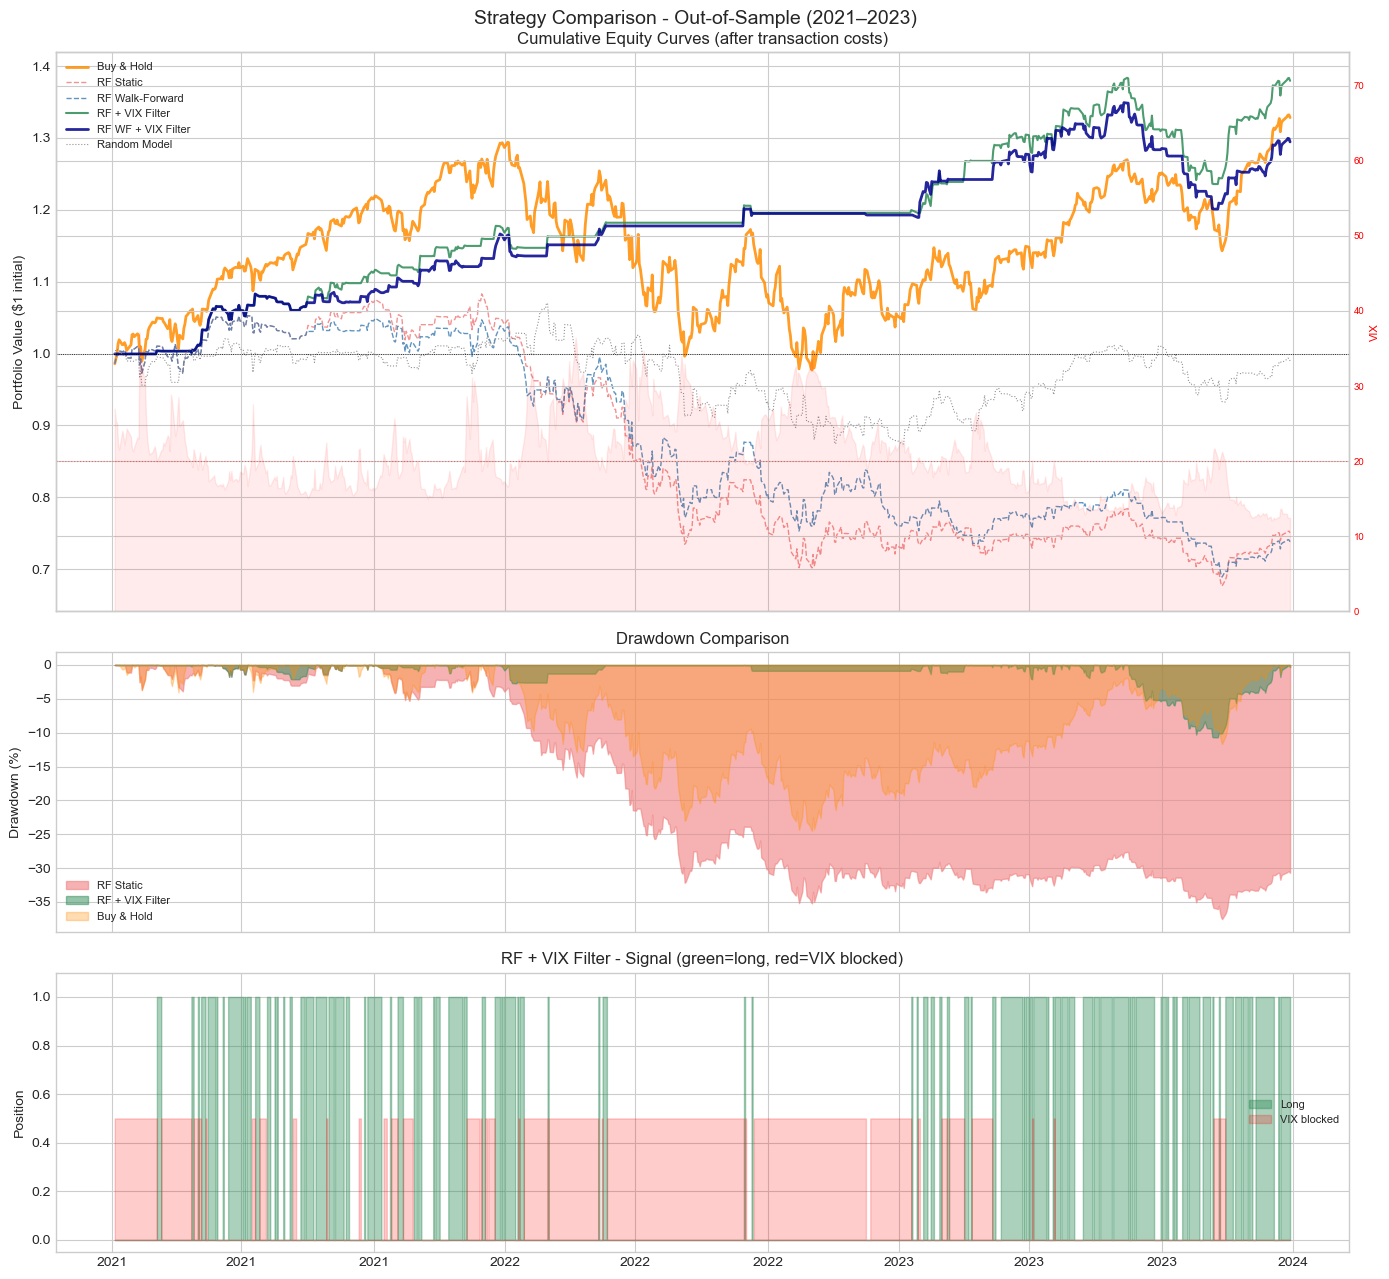

Figure 13 saved.


In [75]:
# Equity curves
backtest['eq_bh']       = (1 + backtest['bh_return']).cumprod()
backtest['eq_random']   = (1 + backtest['random_return']).cumprod()
backtest['eq_static']   = (1 + backtest['rf_static_return']).cumprod()
backtest['eq_wf']       = (1 + backtest['wf_return']).cumprod()
backtest['eq_vix']      = (1 + backtest['vix_return']).cumprod()
backtest['eq_combined'] = (1 + backtest['combined_return']).cumprod()

for col, eq_col in [('dd_static','eq_static'), ('dd_vix','eq_vix'), ('dd_bh','eq_bh')]:
    rm = backtest[eq_col].cummax()
    backtest[col] = (backtest[eq_col] - rm) / rm

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1.5, 1.5]})
fig.suptitle(f'Strategy Comparison - Out-of-Sample ({TEST_START[:4]}–2023)', fontsize=14)

plot_map = [
    ('eq_bh',       'Buy & Hold',         'darkorange', 2.0, '-'),
    ('eq_static',   'RF Static',          'lightcoral', 1.0, '--'),
    ('eq_wf',       'RF Walk-Forward',    'steelblue',  1.0, '--'),
    ('eq_vix',      'RF + VIX Filter',    'seagreen',   1.5, '-'),
    ('eq_combined', 'RF WF + VIX Filter', 'darkblue',   2.0, '-'),
    ('eq_random',   'Random Model',       'gray',       0.8, ':'),
]
for col, label, color, lw, ls in plot_map:
    axes[0].plot(backtest.index, backtest[col], color=color, linewidth=lw,
                 linestyle=ls, label=label, alpha=0.85)
axes[0].axhline(1, color='black', linewidth=0.6, linestyle=':')
axes[0].set_ylabel('Portfolio Value ($1 initial)')
axes[0].set_title('Cumulative Equity Curves (after transaction costs)')
axes[0].legend(fontsize=8, loc='upper left')

ax0b = axes[0].twinx()
ax0b.fill_between(backtest.index, backtest['vix'], alpha=0.08, color='red')
ax0b.axhline(VIX_THRESHOLD, color='red', linewidth=0.8, linestyle=':', alpha=0.5)
ax0b.set_ylabel('VIX', color='red', fontsize=8)
ax0b.tick_params(axis='y', labelcolor='red', labelsize=7)
ax0b.set_ylim(0, backtest['vix'].max() * 2)

axes[1].fill_between(backtest.index, backtest['dd_static'] * 100,
                      color='lightcoral', alpha=0.6, label='RF Static')
axes[1].fill_between(backtest.index, backtest['dd_vix'] * 100,
                      color='seagreen', alpha=0.5, label='RF + VIX Filter')
axes[1].fill_between(backtest.index, backtest['dd_bh'] * 100,
                      color='darkorange', alpha=0.3, label='Buy & Hold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown Comparison')
axes[1].legend(fontsize=8)

axes[2].fill_between(backtest.index, backtest['vix_signal'],
                      step='post', color='seagreen', alpha=0.4, label='Long')
axes[2].fill_between(backtest.index,
                      (backtest['vix'] > VIX_THRESHOLD).astype(int) * 0.5,
                      step='post', color='red', alpha=0.2, label='VIX blocked')
axes[2].set_ylabel('Position')
axes[2].set_title('RF + VIX Filter - Signal (green=long, red=VIX blocked)')
axes[2].set_ylim(-0.05, 1.1)
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig13_equity_curves_all_variants.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 13 saved.')

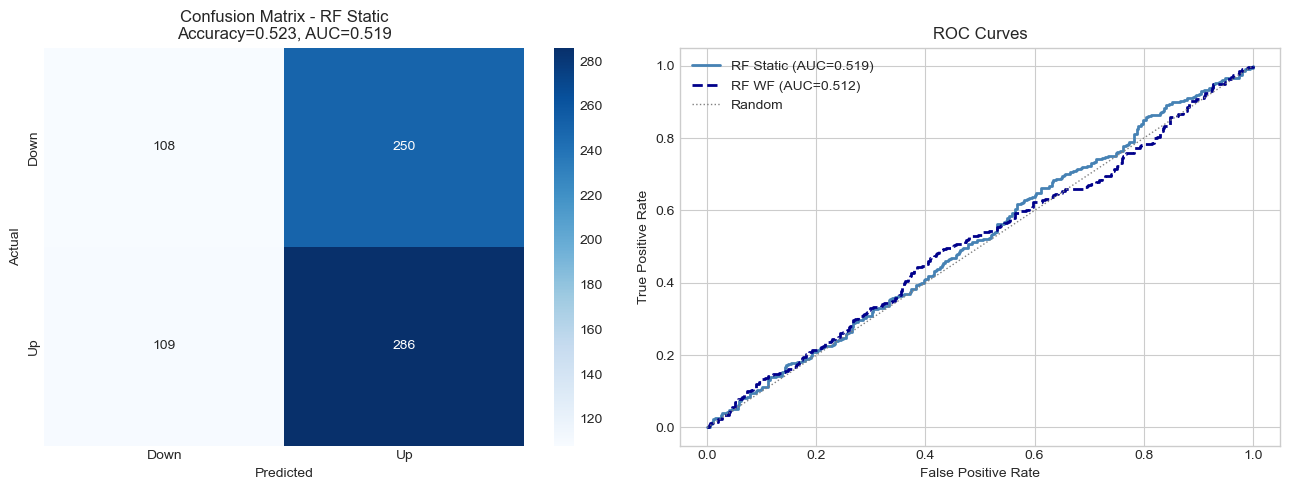

Figure 14 saved.


In [76]:
# Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_static)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix - RF Static\nAccuracy={acc_static:.3f}, AUC={auc_static:.3f}')

fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_static)
fpr_w, tpr_w, _ = roc_curve(y_test, wf_probas)
axes[1].plot(fpr_s, tpr_s, color='steelblue', lw=2, label=f'RF Static (AUC={auc_static:.3f})')
axes[1].plot(fpr_w, tpr_w, color='darkblue',  lw=2, linestyle='--', label=f'RF WF (AUC={wf_auc:.3f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle=':', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 14 saved.')

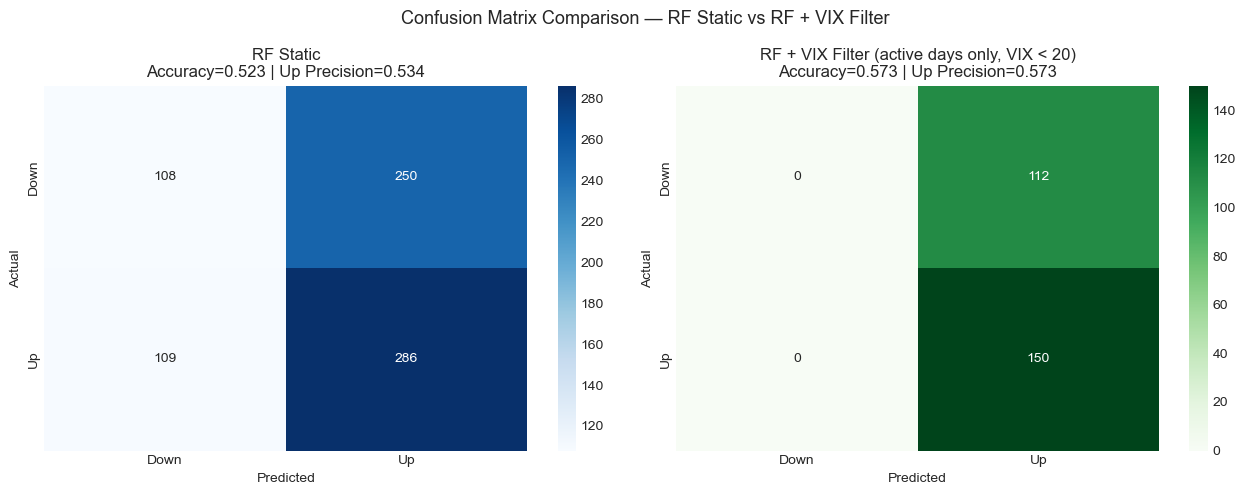

RF Static        — Up Precision: 0.534 | Total predictions: 753
RF + VIX Filter  — Up Precision: 0.573 | Active days: 262 (34.8%)

Precision improvement: +3.9 percentage points


In [77]:
# -------------------------------------------------------
# Figure: Side-by-side CM — Static vs VIX Filter
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- RF Static ---
cm_static = confusion_matrix(y_test, y_pred_static)
sns.heatmap(cm_static, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'],
            yticklabels=['Down', 'Up'],
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Compute precision on Up calls
tp_s = cm_static[1, 1]
fp_s = cm_static[0, 1]
prec_s = tp_s / (tp_s + fp_s) if (tp_s + fp_s) > 0 else 0
axes[0].set_title(
    f'RF Static\n'
    f'Accuracy={acc_static:.3f} | Up Precision={prec_s:.3f}'
)

# --- RF + VIX Filter ---
# The VIX filter only trades on a subset of days
# On flat days the model effectively predicted the market correctly
# by staying out — we evaluate only on days the filter was active
vix_active_idx = backtest[backtest['vix_signal'] == 1].index
y_test_vix     = y_test.loc[vix_active_idx]
y_pred_vix     = pd.Series(y_pred_static, index=y_test.index).loc[vix_active_idx]

cm_vix = confusion_matrix(y_test_vix, y_pred_vix)
sns.heatmap(cm_vix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Down', 'Up'],
            yticklabels=['Down', 'Up'],
            ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Precision on active days
tp_v = cm_vix[1, 1]
fp_v = cm_vix[0, 1]
prec_v = tp_v / (tp_v + fp_v) if (tp_v + fp_v) > 0 else 0
acc_vix = accuracy_score(y_test_vix, y_pred_vix)
axes[1].set_title(
    f'RF + VIX Filter (active days only, VIX < {VIX_THRESHOLD})\n'
    f'Accuracy={acc_vix:.3f} | Up Precision={prec_v:.3f}'
)

plt.suptitle('Confusion Matrix Comparison — RF Static vs RF + VIX Filter', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_cm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f'RF Static        — Up Precision: {prec_s:.3f} | Total predictions: {len(y_test)}')
print(f'RF + VIX Filter  — Up Precision: {prec_v:.3f} | Active days: {len(y_test_vix)} ({len(y_test_vix)/len(y_test)*100:.1f}%)')
print(f'\nPrecision improvement: {(prec_v - prec_s)*100:+.1f} percentage points')

***Remark***
the VIX filter only activates on days when the RF already predicted Up, hence the 0's

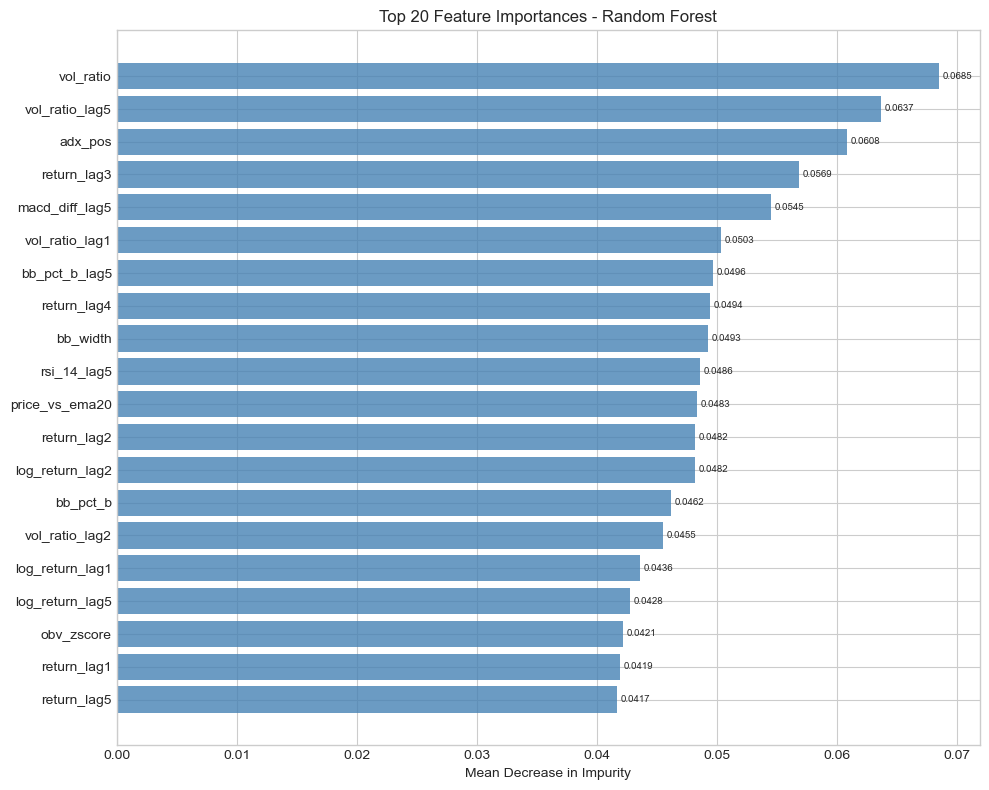

Top 10 features:
       feature  importance
     vol_ratio      0.0685
vol_ratio_lag5      0.0637
       adx_pos      0.0608
   return_lag3      0.0569
macd_diff_lag5      0.0545
vol_ratio_lag1      0.0503
 bb_pct_b_lag5      0.0496
   return_lag4      0.0494
      bb_width      0.0493
   rsi_14_lag5      0.0486


In [ ]:
imp_df = pd.DataFrame({
    'feature'    : selected_features,
    'importance' : best_rf.feature_importances_
}).sort_values('importance', ascending=False)

top_n = min(20, len(imp_df))
top20 = imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['feature'][::-1], top20['importance'][::-1],
               color='steelblue', alpha=0.8)
for bar, val in zip(bars, top20['importance'][::-1]):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=7)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title(f'Top {top_n} Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(imp_df.head(10).to_string(index=False))

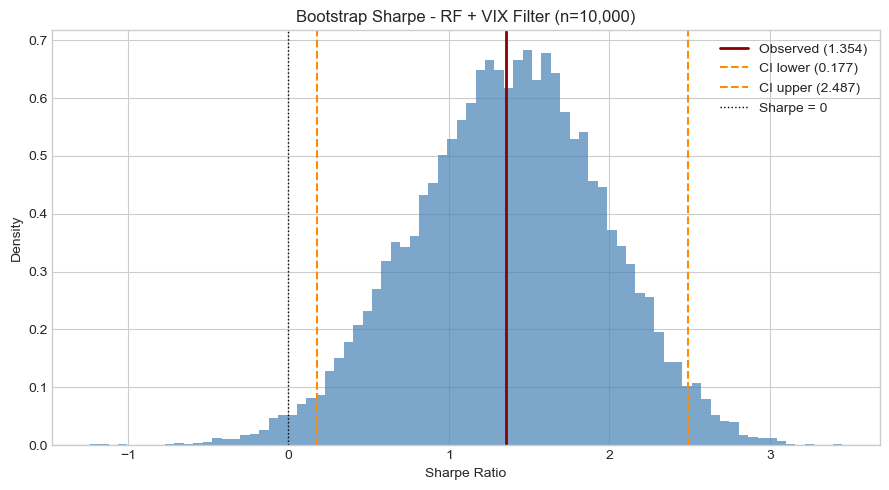

Figure 16 saved.


In [79]:
# Bootstrap Sharpe distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_sharpes, bins=80, color='steelblue', alpha=0.7, edgecolor='none', density=True)
ax.axvline(obs_sharpe, color='darkred',    lw=2,   label=f'Observed ({obs_sharpe:.3f})')
ax.axvline(ci_lower,   color='darkorange', lw=1.5, linestyle='--', label=f'CI lower ({ci_lower:.3f})')
ax.axvline(ci_upper,   color='darkorange', lw=1.5, linestyle='--', label=f'CI upper ({ci_upper:.3f})')
ax.axvline(0,          color='black',      lw=1,   linestyle=':',  label='Sharpe = 0')
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Density')
ax.set_title(f'Bootstrap Sharpe - RF + VIX Filter (n={N_BOOTSTRAP:,})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig16_bootstrap_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 16 saved.')

## 13. Save Everything

In [ ]:
joblib.dump(best_rf,  DATA_DIR / 'rf_best_model.pkl')
joblib.dump(selector, DATA_DIR / 'feature_selector.pkl')

backtest.to_csv(DATA_DIR / 'backtest_all_variants.csv')
results_df.to_csv(DATA_DIR / 'performance_metrics_all_variants.csv')
annual.to_csv(DATA_DIR / 'annual_performance.csv')
imp_df.to_csv(DATA_DIR / 'feature_importance.csv', index=False)

print('Saved to data/ folder:')
print('  rf_best_model.pkl')
print('  feature_selector.pkl')
print('  backtest_all_variants.csv')
print('  performance_metrics_all_variants.csv')
print('  annual_performance.csv')
print('  feature_importance.csv')
print('\nPhase 3 complete.')

Saved to data/ folder:
  rf_best_model.pkl
  feature_selector.pkl
  backtest_all_variants.csv
  performance_metrics_all_variants.csv
  annual_performance.csv
  feature_importance.csv

Phase 3 complete.
